# Module A Report: Lightweight DBMS with B+ Tree Index

## Introduction
This notebook documents the B+ Tree implementation, benchmarking against a brute-force baseline, and Graphviz visualization outputs.

In [7]:
from database import BPlusTree, PerformanceAnalyzer
import pandas as pd
import matplotlib.pyplot as plt

## Implementation Details
Core methods implemented in `database/bplustree.py` include insertion, deletion with rebalance, exact search, update, range query, and visualization.

In [8]:
tree = BPlusTree(order=4)
for key in [10, 20, 5, 6, 12, 30, 7, 17]:
    tree.insert(key, {'id': key, 'score': key * 10})

print('search(12):', tree.search(12))
print('range_query(6, 17):', tree.range_query(6, 17))
tree.delete(6)
print('after delete(6), get_all():', tree.get_all())

search(12): {'id': 12, 'score': 120}
range_query(6, 17): [(6, {'id': 6, 'score': 60}), (7, {'id': 7, 'score': 70}), (10, {'id': 10, 'score': 100}), (12, {'id': 12, 'score': 120}), (17, {'id': 17, 'score': 170})]
after delete(6), get_all(): [(5, {'id': 5, 'score': 50}), (7, {'id': 7, 'score': 70}), (10, {'id': 10, 'score': 100}), (12, {'id': 12, 'score': 120}), (17, {'id': 17, 'score': 170}), (20, {'id': 20, 'score': 200}), (30, {'id': 30, 'score': 300})]


## Performance Analysis
Benchmark B+ Tree vs BruteForceDB for insert/search/delete/range query and memory usage.

In [9]:
analyzer = PerformanceAnalyzer(order=16, seed=42)
results = analyzer.run(sizes=[100, 1000, 5000], searches=200, deletes=100, ranges=100)
df = pd.DataFrame(analyzer.to_rows(results))
df

,size,structure,insert_time_ms,search_time_ms,delete_time_ms,range_time_ms,peak_memory_kb
0,100,BPlusTree,1.165750,0.065750,1.843417,1.260750,17.876953
1,100,BruteForceDB,0.310709,0.190208,0.189667,0.932416,6.609375
2,1000,BPlusTree,109.295250,0.104750,18.224458,8.490416,321.438477
3,1000,BruteForceDB,72.214625,2.437042,5.984375,7.566458,280.234375
4,5000,BPlusTree,1076.589042,0.126667,104.718375,52.196083,1705.787109
5,5000,BruteForceDB,2719.725750,11.326417,57.461084,43.174792,1629.765625


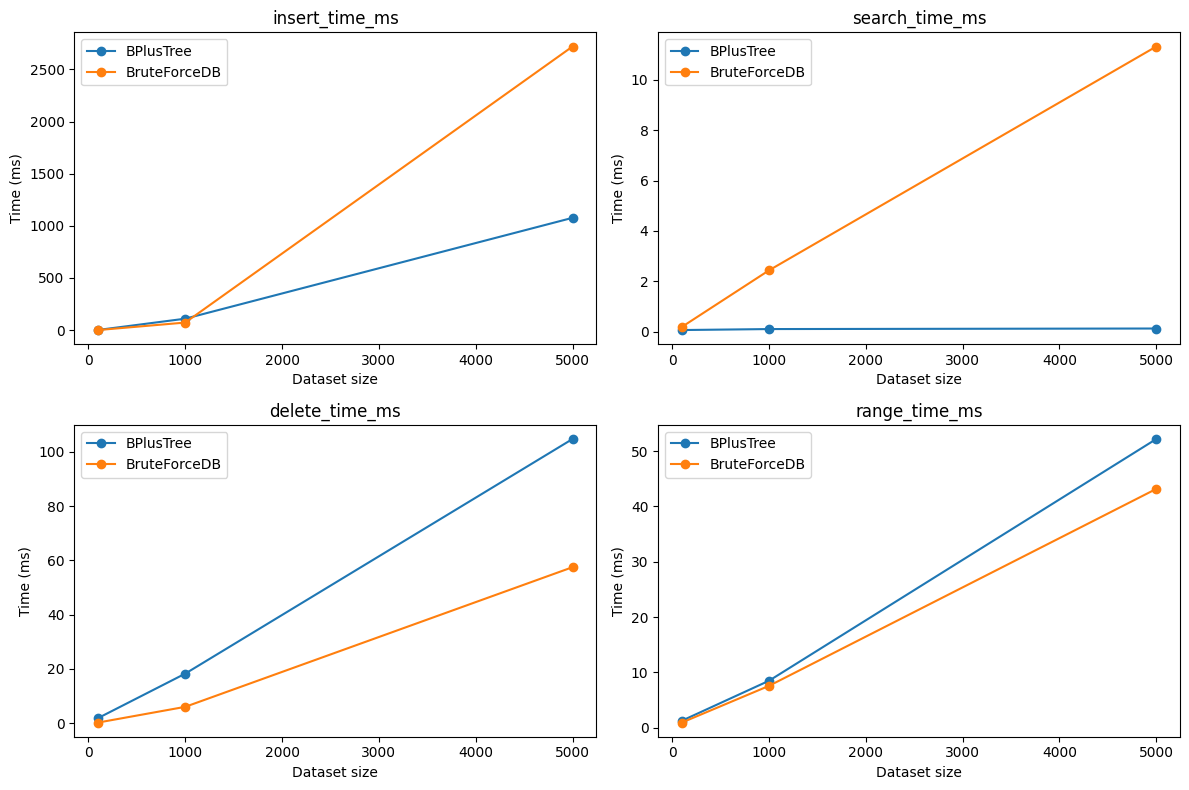

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
metrics = ['insert_time_ms', 'search_time_ms', 'delete_time_ms', 'range_time_ms']
axes = axes.flatten()
for ax, metric in zip(axes, metrics):
    for structure in df['structure'].unique():
        sub = df[df['structure'] == structure]
        ax.plot(sub['size'], sub[metric], marker='o', label=structure)
    ax.set_title(metric)
    ax.set_xlabel('Dataset size')
    ax.set_ylabel('Time (ms)')
    ax.legend()

plt.tight_layout()
plt.show()

## Tree Visualization
Use Graphviz to render and inspect B+ Tree structure and leaf linkage.

In [13]:
import importlib
import database.bplustree as bpt_mod

# Reload module so notebook uses latest visualization fix from disk.
importlib.reload(bpt_mod)
BPlusTree = bpt_mod.BPlusTree
print('Using BPlusTree from:', bpt_mod.__file__)

Using BPlusTree from: /Users/umangshikarvar/Desktop/Module A/db_management_system/database/bplustree.py


In [14]:
# Recreate tree from reloaded class to avoid stale in-memory methods.
tree = BPlusTree(order=4)
for key in [10, 20, 5, 6, 12, 30, 7, 17]:
    tree.insert(key, {'id': key, 'score': key * 10})

tree.visualize_tree(output_path='bplustree_demo', view=False)
print('Generated bplustree_demo.png')

Generated bplustree_demo.png


## Conclusion
Summarize complexity findings, implementation challenges, and future improvements here.

Add your video demo link in this section before final submission.